<a href="https://colab.research.google.com/github/lessleyH/energy-reliability-systems-/blob/main/01_ercot_load_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ERCOT Load Stress Analysis

## Goal
Explore ERCOT hourly load behavior and identify stress patterns, volatility, and anomalous load conditions.

## Data Source
- ERCOT Native Load Data

## Questions
- When does ERCOT experience the largest load ramps?
- What hours are most volatile?
- How do stress days differ from normal days?

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

import os
import zipfile

In [3]:
os.listdir('/content/drive/MyDrive/energy-reliability-systems/data')

['Native_Load_2026.zip']

In [4]:
zip_path = '/content/drive/MyDrive/energy-reliability-systems/data/Native_Load_2026.zip'

In [5]:
import zipfile
import os

extract_path = '/content/ercot_data'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted!")
print(os.listdir(extract_path))

Files extracted!
['Native_Load_2026.xlsx']


In [7]:
import os

os.listdir('/content/ercot_data')

['Native_Load_2026.xlsx']

In [18]:


file_path = '/content/ercot_data/Native_Load_2026.xlsx'

df = pd.read_excel(file_path)

df.head()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,01/01/2026 01:00,11461.463276,1643.277008,7814.653003,1579.066591,11773.493994,3528.166703,7173.595238,1326.181616,46299.897428
1,01/01/2026 02:00,11515.172175,1656.302851,7758.134747,1567.666284,11792.093557,3548.092983,7134.164250,1322.195876,46293.822724
2,01/01/2026 03:00,11466.832519,1657.078993,7695.940461,1562.078533,11764.041621,3570.660837,7075.617140,1323.453644,46115.703748
3,01/01/2026 04:00,11465.641216,1668.547695,7759.513872,1589.652494,11800.767688,3600.950925,7054.814804,1328.728708,46268.617401
4,01/01/2026 05:00,11519.666567,1689.658245,7810.204524,1629.986285,11947.174576,3627.452637,7126.680801,1344.177741,46695.001375


In [19]:
df.columns

Index(['Hour Ending', 'COAST', 'EAST', 'FWEST', 'NORTH', 'NCENT', 'SOUTH',
       'SCENT', 'WEST', 'ERCOT'],
      dtype='object')

In [20]:
# Replace 24:00 with 00:00
df['Hour Ending'] = df['Hour Ending'].str.replace('24:00', '00:00')

# Convert to datetime
df['Hour Ending'] = pd.to_datetime(df['Hour Ending'])

df.head()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,2026-01-01 01:00:00,11461.463276,1643.277008,7814.653003,1579.066591,11773.493994,3528.166703,7173.595238,1326.181616,46299.897428
1,2026-01-01 02:00:00,11515.172175,1656.302851,7758.134747,1567.666284,11792.093557,3548.092983,7134.164250,1322.195876,46293.822724
2,2026-01-01 03:00:00,11466.832519,1657.078993,7695.940461,1562.078533,11764.041621,3570.660837,7075.617140,1323.453644,46115.703748
3,2026-01-01 04:00:00,11465.641216,1668.547695,7759.513872,1589.652494,11800.767688,3600.950925,7054.814804,1328.728708,46268.617401
4,2026-01-01 05:00:00,11519.666567,1689.658245,7810.204524,1629.986285,11947.174576,3627.452637,7126.680801,1344.177741,46695.001375


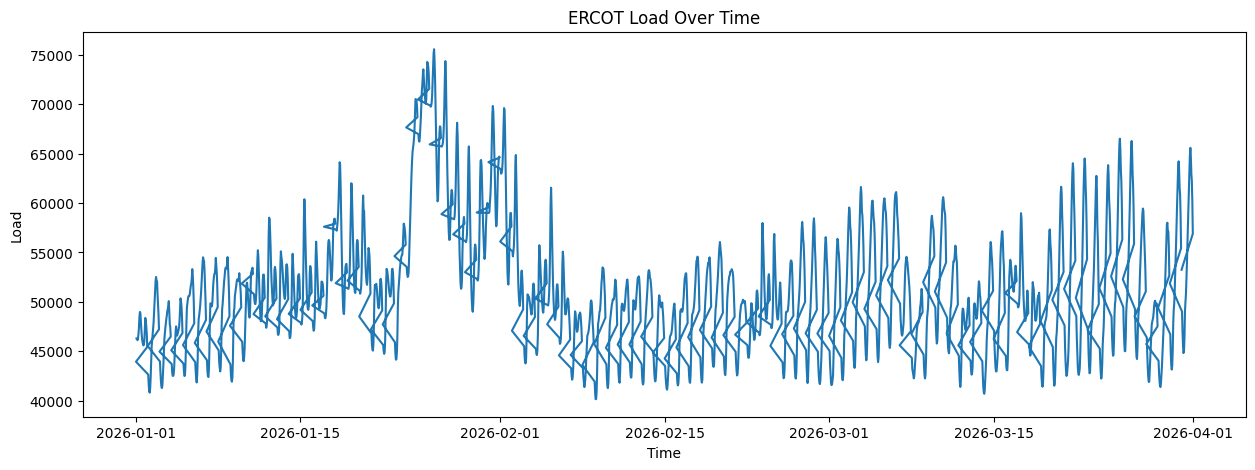

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df['Hour Ending'], df['ERCOT'])

plt.title('ERCOT Load Over Time')
plt.xlabel('Time')
plt.ylabel('Load')

plt.show()

In [22]:
df.loc[df['ERCOT'].idxmax()]

,608
Hour Ending,2026-01-26 09:00:00
COAST,17478.651314
EAST,3122.961405
FWEST,5121.35882
NORTH,1858.729612
NCENT,25003.100901
SOUTH,6491.046074
SCENT,14220.19877
WEST,2275.523191
ERCOT,75571.570086


In [24]:
df['Hour'] = df['Hour Ending'].dt.hour

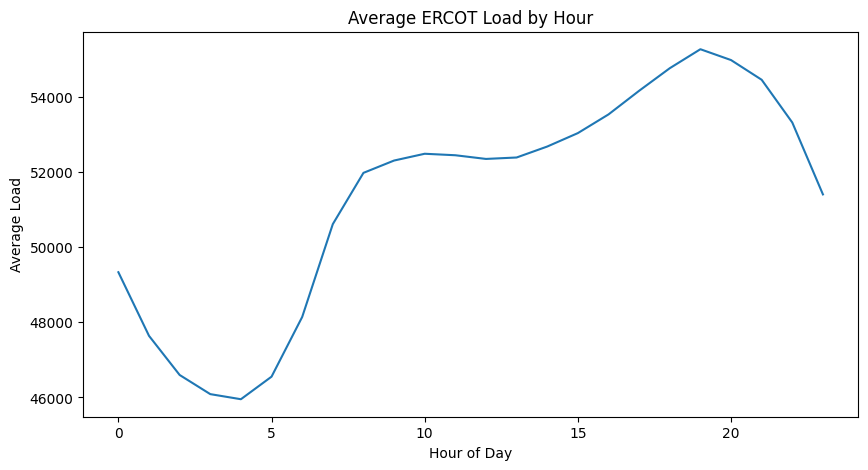

In [25]:
hourly_avg = df.groupby('Hour')['ERCOT'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values)

plt.title('Average ERCOT Load by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Load')

plt.show()

ERCOT demand exhibits strong daily coordination patterns driven by collective human activity, with significant morning and evening ramp periods. Extreme weather events amplify these coordinated behaviors and create large demand spikes that may stress grid reliability.


In [26]:
df['Load_Change'] = df['ERCOT'].diff()

df[['Hour Ending', 'ERCOT', 'Load_Change']].head()

,Hour Ending,ERCOT,Load_Change
0,2026-01-01 01:00:00,46299.897428,NaN
1,2026-01-01 02:00:00,46293.822724,-6.074704
2,2026-01-01 03:00:00,46115.703748,-178.118976
3,2026-01-01 04:00:00,46268.617401,152.913653
4,2026-01-01 05:00:00,46695.001375,426.383974


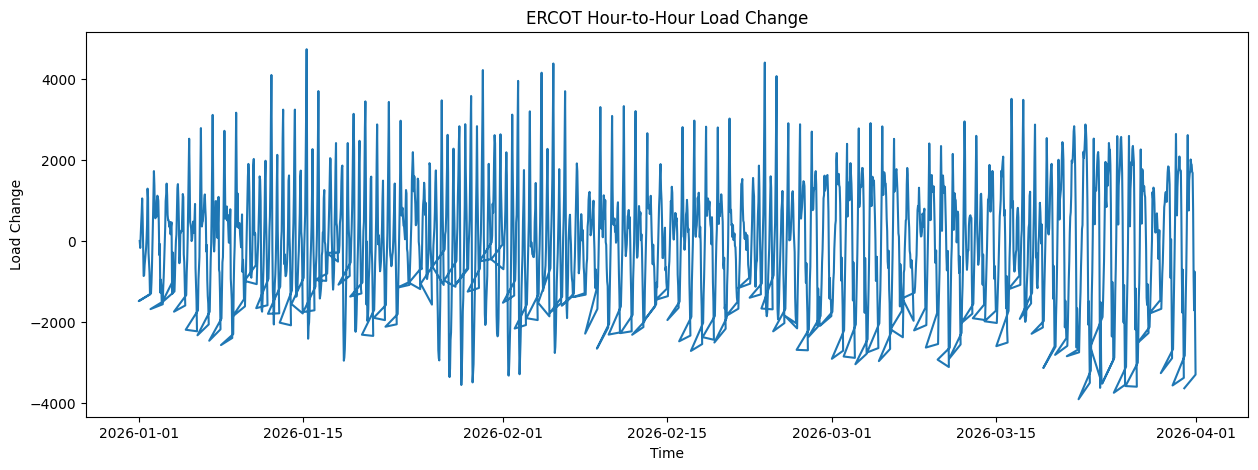

In [27]:
plt.figure(figsize=(15,5))

plt.plot(df['Hour Ending'], df['Load_Change'])

plt.title('ERCOT Hour-to-Hour Load Change')
plt.xlabel('Time')
plt.ylabel('Load Change')

plt.show()

In [28]:
df.loc[df['Load_Change'].idxmax()]

,342
Hour Ending,2026-01-15 07:00:00
COAST,13764.213691
EAST,2257.343803
FWEST,7929.321101
NORTH,1934.024575
NCENT,17501.882541
SOUTH,4270.344171
SCENT,9115.988482
WEST,1624.439231
ERCOT,58397.557596


In [29]:
df.loc[df['Load_Change'].idxmin()]

,1942
Hour Ending,2026-03-22 00:00:00
COAST,12609.488702
EAST,1569.401398
FWEST,7557.139076
NORTH,1455.217397
NCENT,13622.353729
SOUTH,4198.521644
SCENT,7991.813162
WEST,1404.646173
ERCOT,50408.581282


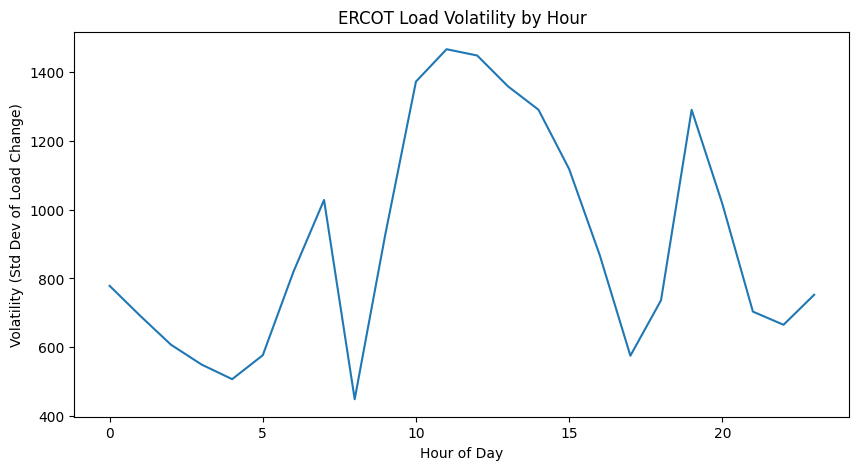

In [30]:
hourly_volatility = df.groupby('Hour')['Load_Change'].std()

plt.figure(figsize=(10,5))

plt.plot(hourly_volatility.index, hourly_volatility.values)

plt.title('ERCOT Load Volatility by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Volatility (Std Dev of Load Change)')

plt.show()

## Initial Observations

ERCOT load exhibits clear cyclical patterns tied to collective human behavior.

However, volatility is not evenly distributed throughout the day.

The highest volatility occurs during major behavioral transition periods:
- morning ramp-up (~9 AM–1 PM)
- evening return-home period (~7 PM)

This suggests that synchronized human activity contributes significantly to system instability and rapid load transitions.

In [31]:
# hıghest load days
daily_load = df.groupby(df['Hour Ending'].dt.date)['ERCOT'].max()

top_days = daily_load.sort_values(ascending=False).head(10)

top_days

,ERCOT
Hour Ending,
2026-01-26,75571.570086
2026-01-27,74369.587797
2026-01-25,74287.726262
2026-01-24,70522.511668
2026-01-31,69823.436411
2026-02-01,69611.887170
2026-01-28,68122.753270
2026-03-25,66514.945317
2026-03-26,66285.882975


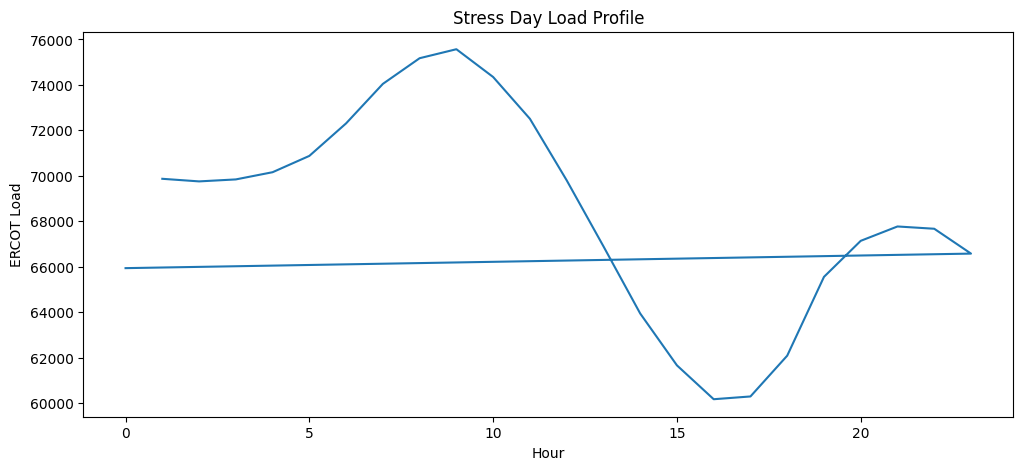

In [32]:
stress_day = df[df['Hour Ending'].dt.date.astype(str) == '2026-01-26']

plt.figure(figsize=(12,5))

plt.plot(stress_day['Hour'], stress_day['ERCOT'])

plt.title('Stress Day Load Profile')
plt.xlabel('Hour')
plt.ylabel('ERCOT Load')

plt.show()

In [33]:
#why does the structure of the day fundamentally change during stress conditions?

In [34]:
df['Date'] = df['Hour Ending'].dt.date

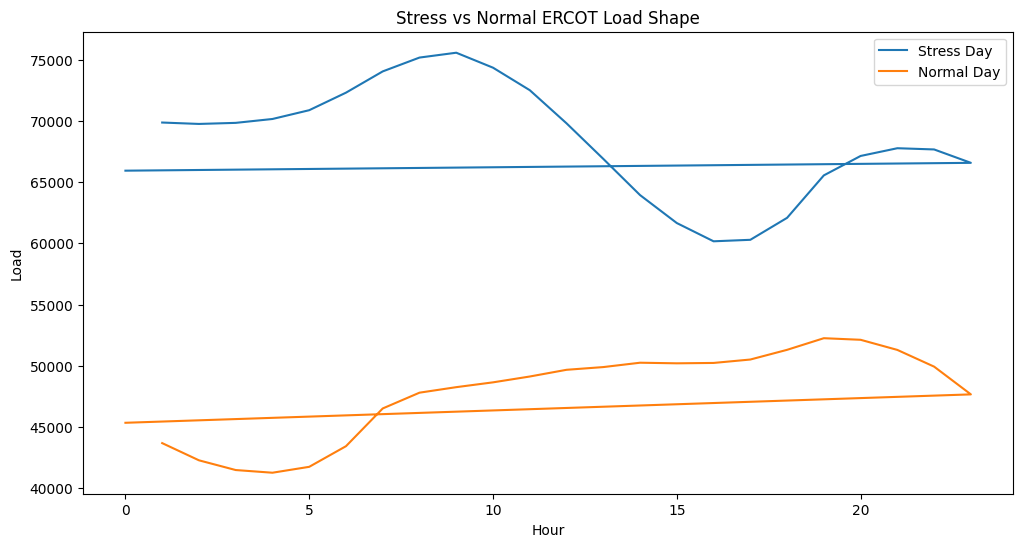

In [35]:
stress_day = df[df['Date'].astype(str) == '2026-01-26']
normal_day = df[df['Date'].astype(str) == '2026-02-10']

plt.figure(figsize=(12,6))

plt.plot(stress_day['Hour'], stress_day['ERCOT'], label='Stress Day')
plt.plot(normal_day['Hour'], normal_day['ERCOT'], label='Normal Day')

plt.legend()

plt.title('Stress vs Normal ERCOT Load Shape')
plt.xlabel('Hour')
plt.ylabel('Load')

plt.show()

Normal day:

* gradual wake-up
* smoother ramp
* broad evening peak
* predictable decay

Stress day:

* demand elevated ALL day
* massive early surge
* sharp collapse
* partial rebound later

Extreme weather events alter normal coordination dynamics in ERCOT demand patterns, producing compressed synchronization effects and abnormal volatility structures.